### Load the panel

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet
from alpha_research.validation import (
    calculate_daily_ic,
    calculate_long_short_spread,
    calculate_quantile_returns,
    summarise_ic,
)

factor_panel = load_parquet(
    PROCESSED_DATA_DIR / "factor_panel.parquet"
)

### Test factors

In [2]:
rank_ic = calculate_daily_ic(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    method="spearman",
    min_observations=30,
)

summarise_ic(rank_ic)

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
0,2634,0.019718,0.277559,0.071042,3.646044,0.555809


In [3]:
pearson_ic = calculate_daily_ic(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    method="pearson",
    min_observations=30,
)

summarise_ic(pearson_ic)

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
0,2634,0.031045,0.286453,0.108376,5.562122,0.558846


Text(0, 0.5, 'Rank IC')

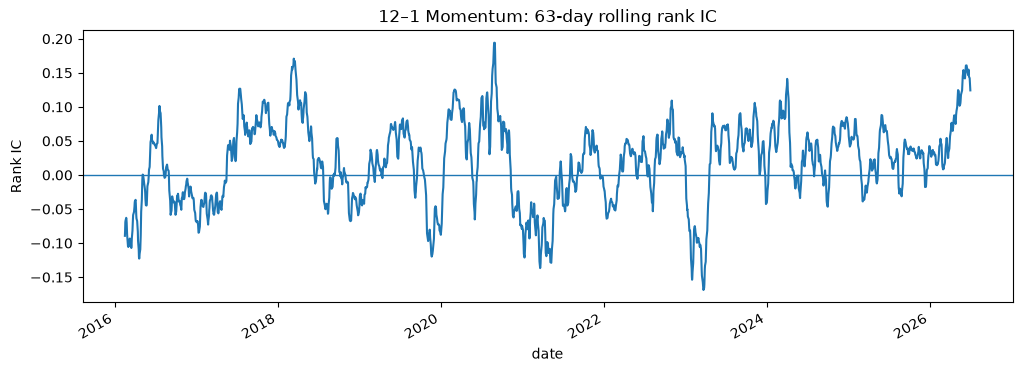

In [4]:
rank_ic["rolling_ic_63"] = (
    rank_ic["ic"]
    .rolling(63, min_periods=30)
    .mean()
)

ax = rank_ic.plot(
    x="date",
    y="rolling_ic_63",
    figsize=(12, 4),
    title="12–1 Momentum: 63-day rolling rank IC",
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Rank IC")

### Quantile return analysis

In [6]:
quantile_returns = calculate_quantile_returns(
    factor_panel,
    factor_column="mom_12_1m_z",
    forward_return_column="forward_ret_5d",
    quantiles=5,
    min_observations=30,
)

quantile_returns.head(10)

,date,quantile,mean_forward_return,observations
0,2016-01-04,1,-0.058507,20
1,2016-01-04,2,-0.044239,19
2,2016-01-04,3,-0.039653,19
3,2016-01-04,4,-0.043141,19
4,2016-01-04,5,-0.030609,20
5,2016-01-05,1,-0.053508,20
6,2016-01-05,2,-0.036827,19
7,2016-01-05,3,-0.031883,19
8,2016-01-05,4,-0.039217,19
9,2016-01-05,5,-0.023184,20


In [7]:
average_quantile_returns = (
    quantile_returns.groupby("quantile")["mean_forward_return"]
    .mean()
)

average_quantile_returns

quantile
1    0.003978
2    0.003281
3    0.003234
4    0.003226
5    0.005296
Name: mean_forward_return, dtype: float64

<Axes: title={'center': 'Average 5-day forward return by momentum quintile'}, xlabel='quantile'>

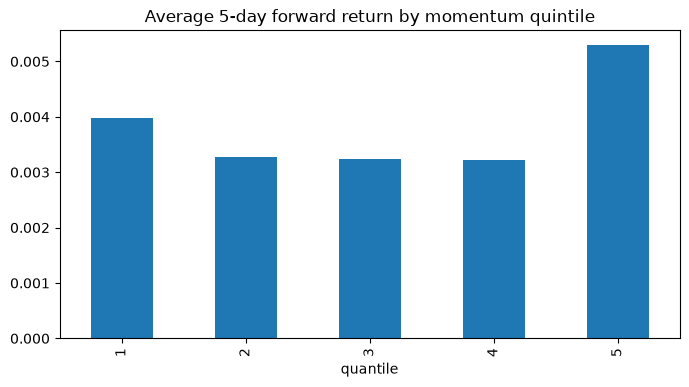

In [8]:
average_quantile_returns.plot(
    kind="bar",
    figsize=(8, 4),
    title="Average 5-day forward return by momentum quintile",
)

In [9]:
long_short = calculate_long_short_spread(
    quantile_returns,
    top_quantile=5,
    bottom_quantile=1,
)

long_short["cumulative_return"] = (
    1.0 + long_short["long_short_return"]
).cumprod()

long_short.tail()

,date,long_short_return,cumulative_return
2629,2026-06-18,-0.040778,11.222514
2630,2026-06-22,-0.044244,10.725984
2631,2026-06-23,0.027195,11.017676
2632,2026-06-24,-0.023534,10.758382
2633,2026-06-25,-0.111337,9.560576


### Run all four factors

In [12]:
factor_columns = {
    "12-1 Momentum": "mom_12_1m_z",
    "3-Month Momentum": "mom_3m_z",
    "1-Month Reversal": "reversal_1m_z",
    "Realised Volatility": "realised_vol_63_z",
}

summary_rows = []

for factor_name, factor_column in factor_columns.items():
    ic = calculate_daily_ic(
        factor_panel,
        factor_column=factor_column,
        forward_return_column="forward_ret_5d",
        method="spearman",
        min_observations=30,
    )

    summary = summarise_ic(ic).iloc[0].to_dict()
    summary["factor"] = factor_name
    summary_rows.append(summary)

ic_summary = pd.DataFrame(summary_rows).set_index("factor")
ic_summary

,count,mean_ic,std_ic,ic_ir,t_stat,positive_fraction
factor,,,,,,
12-1 Momentum,2634.0,0.019718,0.277559,0.071042,3.646044,0.555809
3-Month Momentum,2823.0,0.002779,0.243563,0.011411,0.606264,0.529933
1-Month Reversal,2865.0,0.005303,0.222045,0.023882,1.278315,0.490750
Realised Volatility,2823.0,0.025340,0.292340,0.086680,4.605470,0.544102


## Factor robustness and stability

### Horizon comparison

In [14]:
from alpha_research.validation import (
    calculate_ic_by_horizon,
    calculate_non_overlapping_ic,
    calculate_rolling_ic,
    calculate_subperiod_ic,
)

ImportError: cannot import name 'calculate_ic_by_horizon' from 'alpha_research.validation' (D:\dev\quant_projects\alpha-research-lab\src\alpha_research\validation.py)